# Graded Response Model — WPI (Single Scale)

Fits a single-dimensional GRM to all 116 WPI items. With binary responses (K=2), this is equivalent to a 2PL IRT model.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['TQDM_DISABLE'] = '1'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from plot_helpers import (plot_loss_comparison, plot_forest_discriminations,
                          plot_ability_scatter, plot_ability_distributions,
                          plot_thresholds, plot_individual_abilities,
                          plot_imputation_weights_pcolormesh)

## 1. Load Data

In [2]:
from bayesianquilts.data.wpi import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset shape: {df.shape}")
print(f"Number of people: {num_people}")
print(f"Number of items: {len(item_keys)}")
print(f"Response cardinality: {response_cardinality} (binary 0-1)")
df.head()

Dataset shape: (6019, 117)
Number of people: 6019
Number of items: 116
Response cardinality: 2 (binary 0-1)


person,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,…,Q80,Q81,Q82,Q83,Q84,Q85,Q86,Q87,Q88,Q89,Q90,Q91,Q92,Q93,Q94,Q95,Q96,Q97,Q98,Q99,Q100,Q101,Q102,Q103,Q104,Q105,Q106,Q107,Q108,Q109,Q110,Q111,Q112,Q113,Q114,Q115,Q116
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,1,1,0,0,0,1,1,0,1,0,1,0,1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,1,0,0,…,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,1,1,0
1,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,-1,1,1,1,1,1,1,1,0,0,1,1,0,1,1,…,1,1,1,1,1,0,1,1,0,1,0,0,1,1,1,1,0,1,1,-1,1,1,1,1,1,1,0,1,1,1,1,1,1,0,0,0,0
2,0,0,1,1,0,1,0,0,0,0,1,0,0,1,1,1,1,0,1,1,1,0,0,0,1,1,1,1,1,0,0,1,0,0,0,1,…,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,-1,0,1,0,1,1,0,0,0,0,0,1
3,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0,1,0,…,1,1,1,1,1,0,1,1,1,1,0,1,0,0,0,0,0,1,1,1,0,1,1,1,1,1,1,1,1,0,1,0,1,0,0,0,0
4,0,0,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,0,1,1,…,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 6019


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 6334
N: 6019, Batch size: 256, Steps per epoch: 24


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
    lr_decay_factor=0.975,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Final loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/24 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/24 [00:02<?, ?batch/s, best_loss=inf, loss=21654.8545]

Epoch 1/200 (LR: 0.000200):   4%|▍         | 1/24 [00:02<00:52,  2.30s/batch, best_loss=inf, loss=21654.8545]

Epoch 1/200 (LR: 0.000200):   4%|▍         | 1/24 [00:02<00:52,  2.30s/batch, best_loss=inf, loss=21429.0193]

...

Epoch 200/200 (LR: 0.000200):  58%|█████▊    | 14/24 [00:00<00:00, 135.53batch/s, best_loss=16589.0109, loss=17284.8862]

Epoch 200/200 (LR: 0.000200):  58%|█████▊    | 14/24 [00:00<00:00, 135.53batch/s, best_loss=16589.0109, loss=16992.0982]

Epoch 200/200 (LR: 0.000200):  58%|█████▊    | 14/24 [00:00<00:00, 135.53batch/s, best_loss=16589.0109, loss=8846.1008] 

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---


Final loss: 16580.46
Snapshot saved at epoch 50


In [6]:
model_baseline.save_to_disk('grm_baseline')

In [7]:
# Calibrate baseline model early so we can compute WAIC for mixed imputation
def calibrate_manually(model, n_samples=32, seed=42):
    try:
        surrogate = model.surrogate_distribution_generator(model.params)
        key = jax.random.PRNGKey(seed)
        samples = surrogate.sample(n_samples, seed=key)
        expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
        model.calibrated_expectations = expectations
        model.surrogate_sample = samples
    except KeyError as e:
        print(f"  Warning: surrogate sampling failed ({e}), using point estimates")
        point_estimates = {}
        for key_name, value in model.params.items():
            parts = key_name.split('\\')
            if len(parts) >= 4:
                param_name = parts[0]
                if parts[-2] == 'normal' and parts[-1] == 'loc':
                    point_estimates[param_name] = value
        model.calibrated_expectations = point_estimates

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 4. Fit MICEBayesianLOO Imputation Model

In [8]:
from bayesianquilts.imputation.mice_loo import MICEBayesianLOO

# Convert to pandas with NaN for missing (MICEBayesianLOO expects pandas)
imputation_df = sub_df.select(item_keys).to_pandas()
imputation_df = imputation_df.replace(-1, np.nan)
print(f"Imputation DataFrame shape: {imputation_df.shape}")
print(f"NaN count: {imputation_df.isna().sum().sum()}")

mice_loo = MICEBayesianLOO(
    random_state=42,
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

mice_loo.fit_loo_models(
    X_df=imputation_df,
    n_top_features=30,
    n_jobs=1,
    fit_zero_predictors=True,
    seed=42,
)

print(f"\nFitted variable names: {mice_loo.variable_names[:5]}...")
print(f"Zero-predictor models: {len(mice_loo.zero_predictor_results)}")
print(f"Univariate models: {len(mice_loo.univariate_results)}")

Imputation DataFrame shape: (6019, 116)
NaN count: 6334
Computing feature correlations...


Fitting MICE Bayesian LOO-CV models with Pathfinder
  Variables: 116
  Observations: 6019
  Min obs per model: 5
  Parallel jobs: 1
  Top features per target: 30

Fitting zero-predictor models...
  Scheduling 116 zero-predictor jobs...


  Var 0 (Q1): n_obs=6005, elpd/n=-0.0569


  Var 1 (Q2): n_obs=5996, elpd/n=-0.0589


  Var 2 (Q3): n_obs=5988, elpd/n=-0.0432


...

  Processing Q113 (30 valid predictors)


  Processing Q114 (30 valid predictors)


  Processing Q115 (30 valid predictors)


  Processing Q116 (30 valid predictors)



Fitted variable names: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']...
Zero-predictor models: 116
Univariate models: 3480


In [9]:
mice_loo.save('mice_loo_model.yaml')

In [10]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=mice_loo,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

Item Weights (MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt
--------------------------------------------
Q1              0.654    -0.0465    -0.6839
Q2              0.655    -0.0504    -0.6932
Q3              0.615    -0.0372    -0.5065
Q4              0.627    -0.0412    -0.5614
Q5              0.651    -0.0549    -0.6785
Q6              0.603    -0.0323    -0.4504
Q7              0.580    -0.0183    -0.3430
Q8              0.654    -0.0570    -0.6958
Q9              0.634    -0.0465    -0.5977
Q10             0.623    -0.0372    -0.5406
Q11             0.650    -0.0460    -0.6655
Q12             0.638    -0.0497    -0.6174
Q13             0.644    -0.0512    -0.6433
Q14             0.607    -0.0318    -0.4647
Q15             0.639     0.0650    -0.5043
Q16             0.634    -0.0415    -0.5898
Q17             0.632    -0.0456    -0.5849
Q18             0.652    -0.0480    -0.6771
Q19             0.655    -0.0543    -0.6939
Q20             0.666     0.0474    -0.6449
Q21

## 5. Fit GRM with Analytic Rao-Blackwellized Imputation

In [11]:
model_imputed = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
    imputation_model=mixed_imputation,
)

if snapshot_params is not None:
    print(f"Warm-starting from baseline epoch-{SNAPSHOT_EPOCH} snapshot")

res_imputed = model_imputed.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
    initial_values=snapshot_params,
    lr_decay_factor=0.975,
)

losses_imputed = res_imputed[0]
print(f"Final loss: {losses_imputed[-1]:.2f}")

Warm-starting from baseline epoch-50 snapshot
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/24 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/24 [00:02<?, ?batch/s, best_loss=inf, loss=20392.7486]

Epoch 1/200 (LR: 0.000200):   4%|▍         | 1/24 [00:02<01:07,  2.93s/batch, best_loss=inf, loss=20392.7486]

Epoch 1/200 (LR: 0.000200):   4%|▍         | 1/24 [00:02<01:07,  2.93s/batch, best_loss=inf, loss=20390.0096]

...

Epoch 200/200 (LR: 0.000200):  83%|████████▎ | 20/24 [00:01<00:00, 15.78batch/s, best_loss=16523.5076, loss=16859.9877]

Epoch 200/200 (LR: 0.000200):  92%|█████████▏| 22/24 [00:01<00:00, 16.26batch/s, best_loss=16523.5076, loss=16859.9877]

Epoch 200/200 (LR: 0.000200):  92%|█████████▏| 22/24 [00:01<00:00, 16.26batch/s, best_loss=16523.5076, loss=17183.5342]

Epoch 200/200 (LR: 0.000200):  92%|█████████▏| 22/24 [00:01<00:00, 16.26batch/s, best_loss=16523.5076, loss=8770.5096] 

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---
Final loss: 16519.10


In [12]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

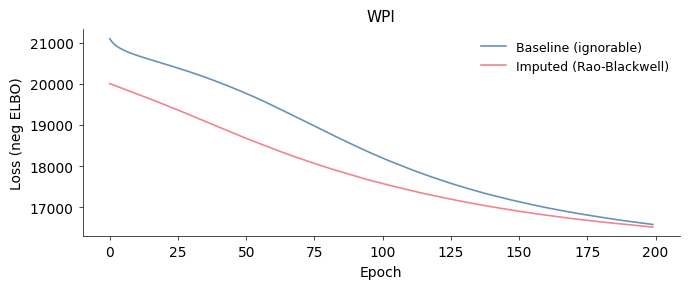

In [13]:
fig = plot_loss_comparison(losses_baseline, losses_imputed, title='WPI')
fig.savefig('loss_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [14]:
# calibrate_manually already defined above; just calibrate the imputed model
calibrate_manually(model_imputed, n_samples=32, seed=102)

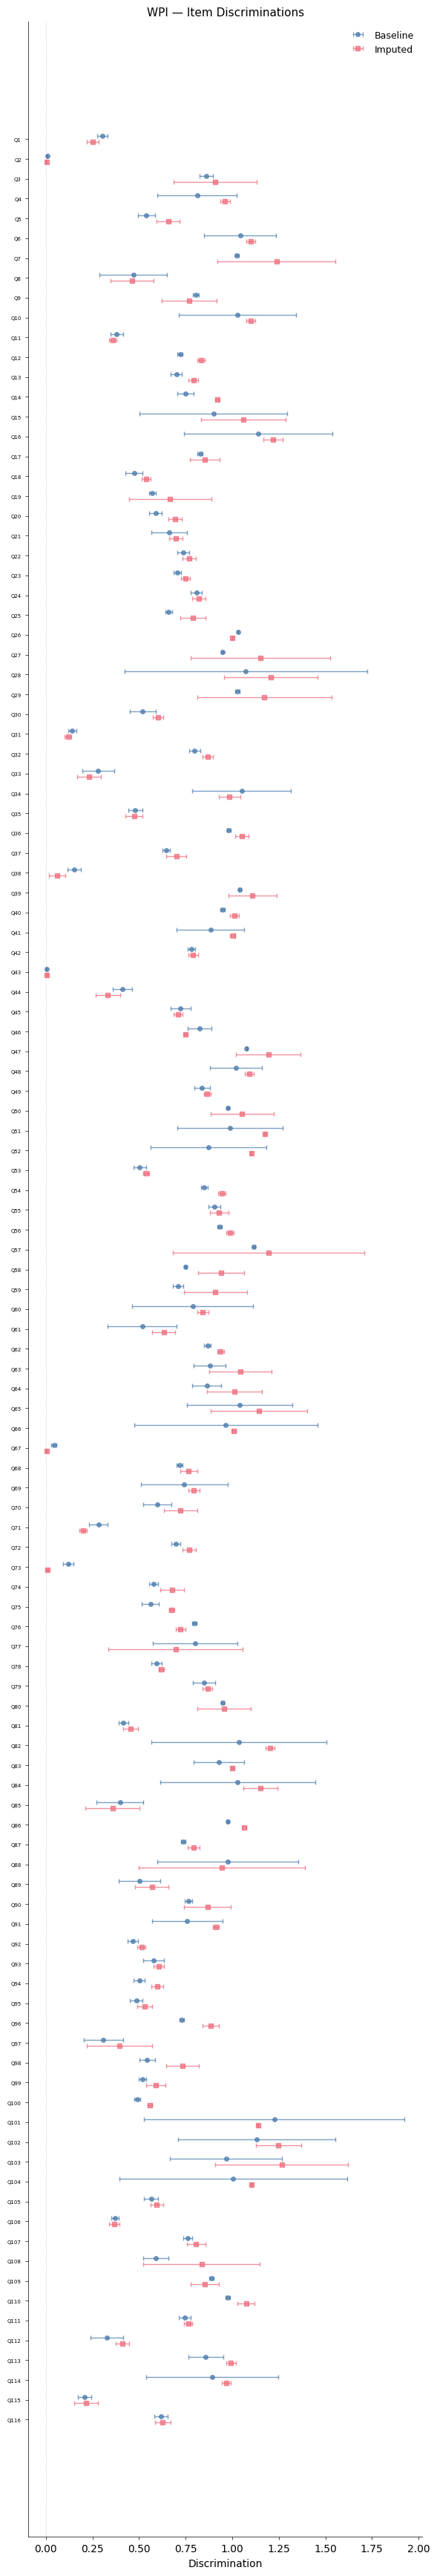

In [15]:
fig = plot_forest_discriminations(item_keys, model_baseline, model_imputed, title='WPI — Item Discriminations')
fig.savefig('item_discriminations.pdf', bbox_inches='tight', dpi=150)
plt.show()

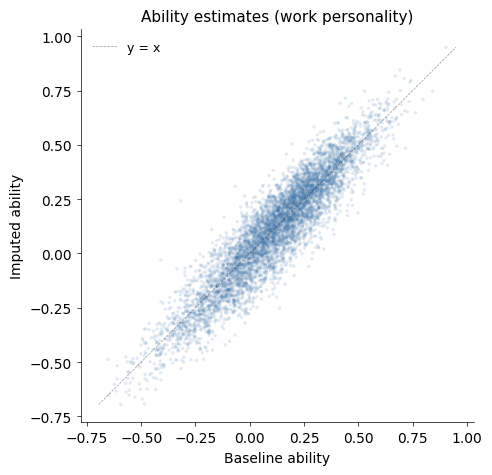

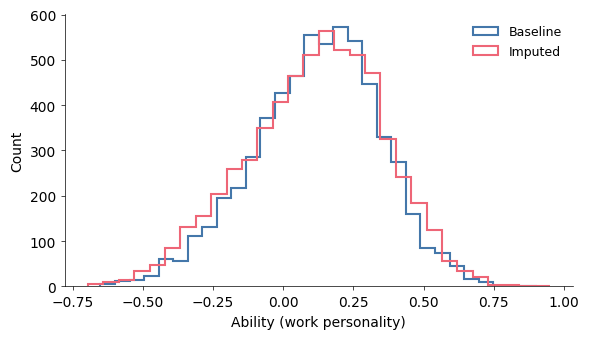

In [16]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig = plot_ability_scatter(ab_base, ab_imp, label='work personality')
fig.savefig('ability_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

fig = plot_ability_distributions(ab_base, ab_imp, label='work personality')
fig.savefig('ability_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

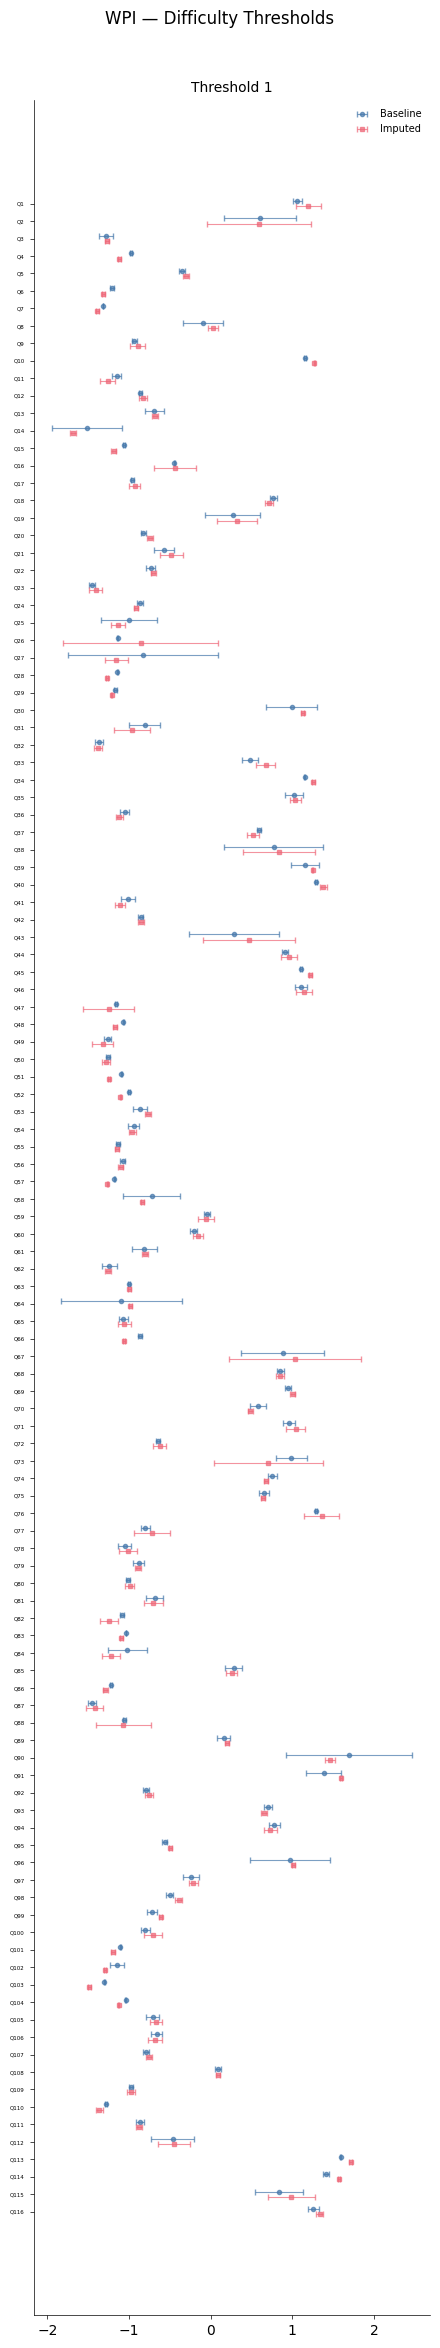

In [17]:
fig = plot_thresholds(item_keys, model_baseline, model_imputed, title='WPI — Difficulty Thresholds')
fig.savefig('difficulty_thresholds.pdf', bbox_inches='tight', dpi=150)
plt.show()

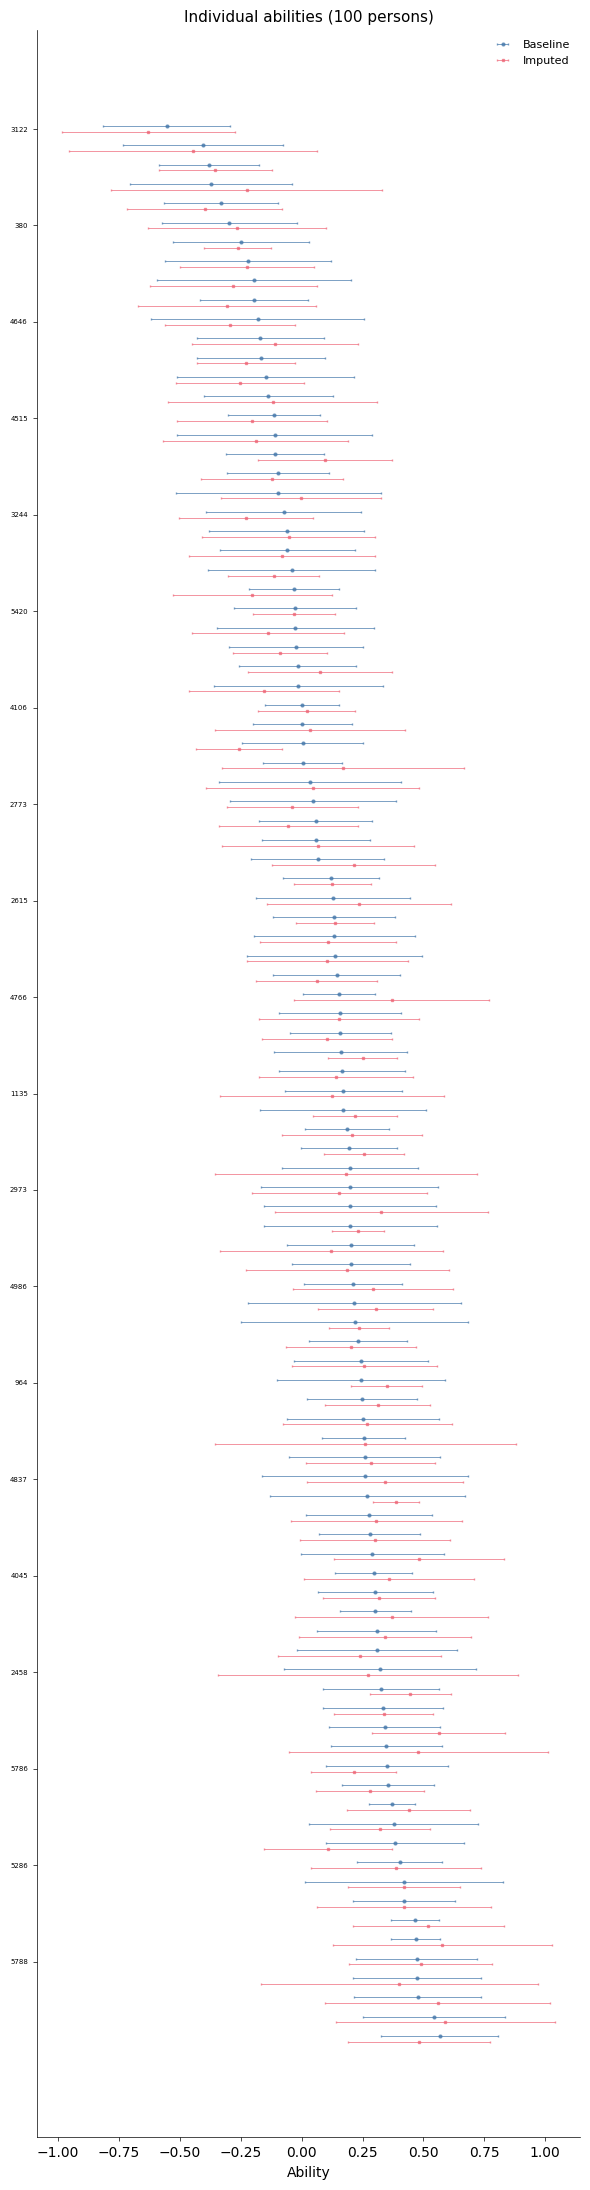

In [18]:
fig = plot_individual_abilities(item_keys, model_baseline, model_imputed)
fig.savefig('individual_abilities.pdf', bbox_inches='tight', dpi=150)
plt.show()

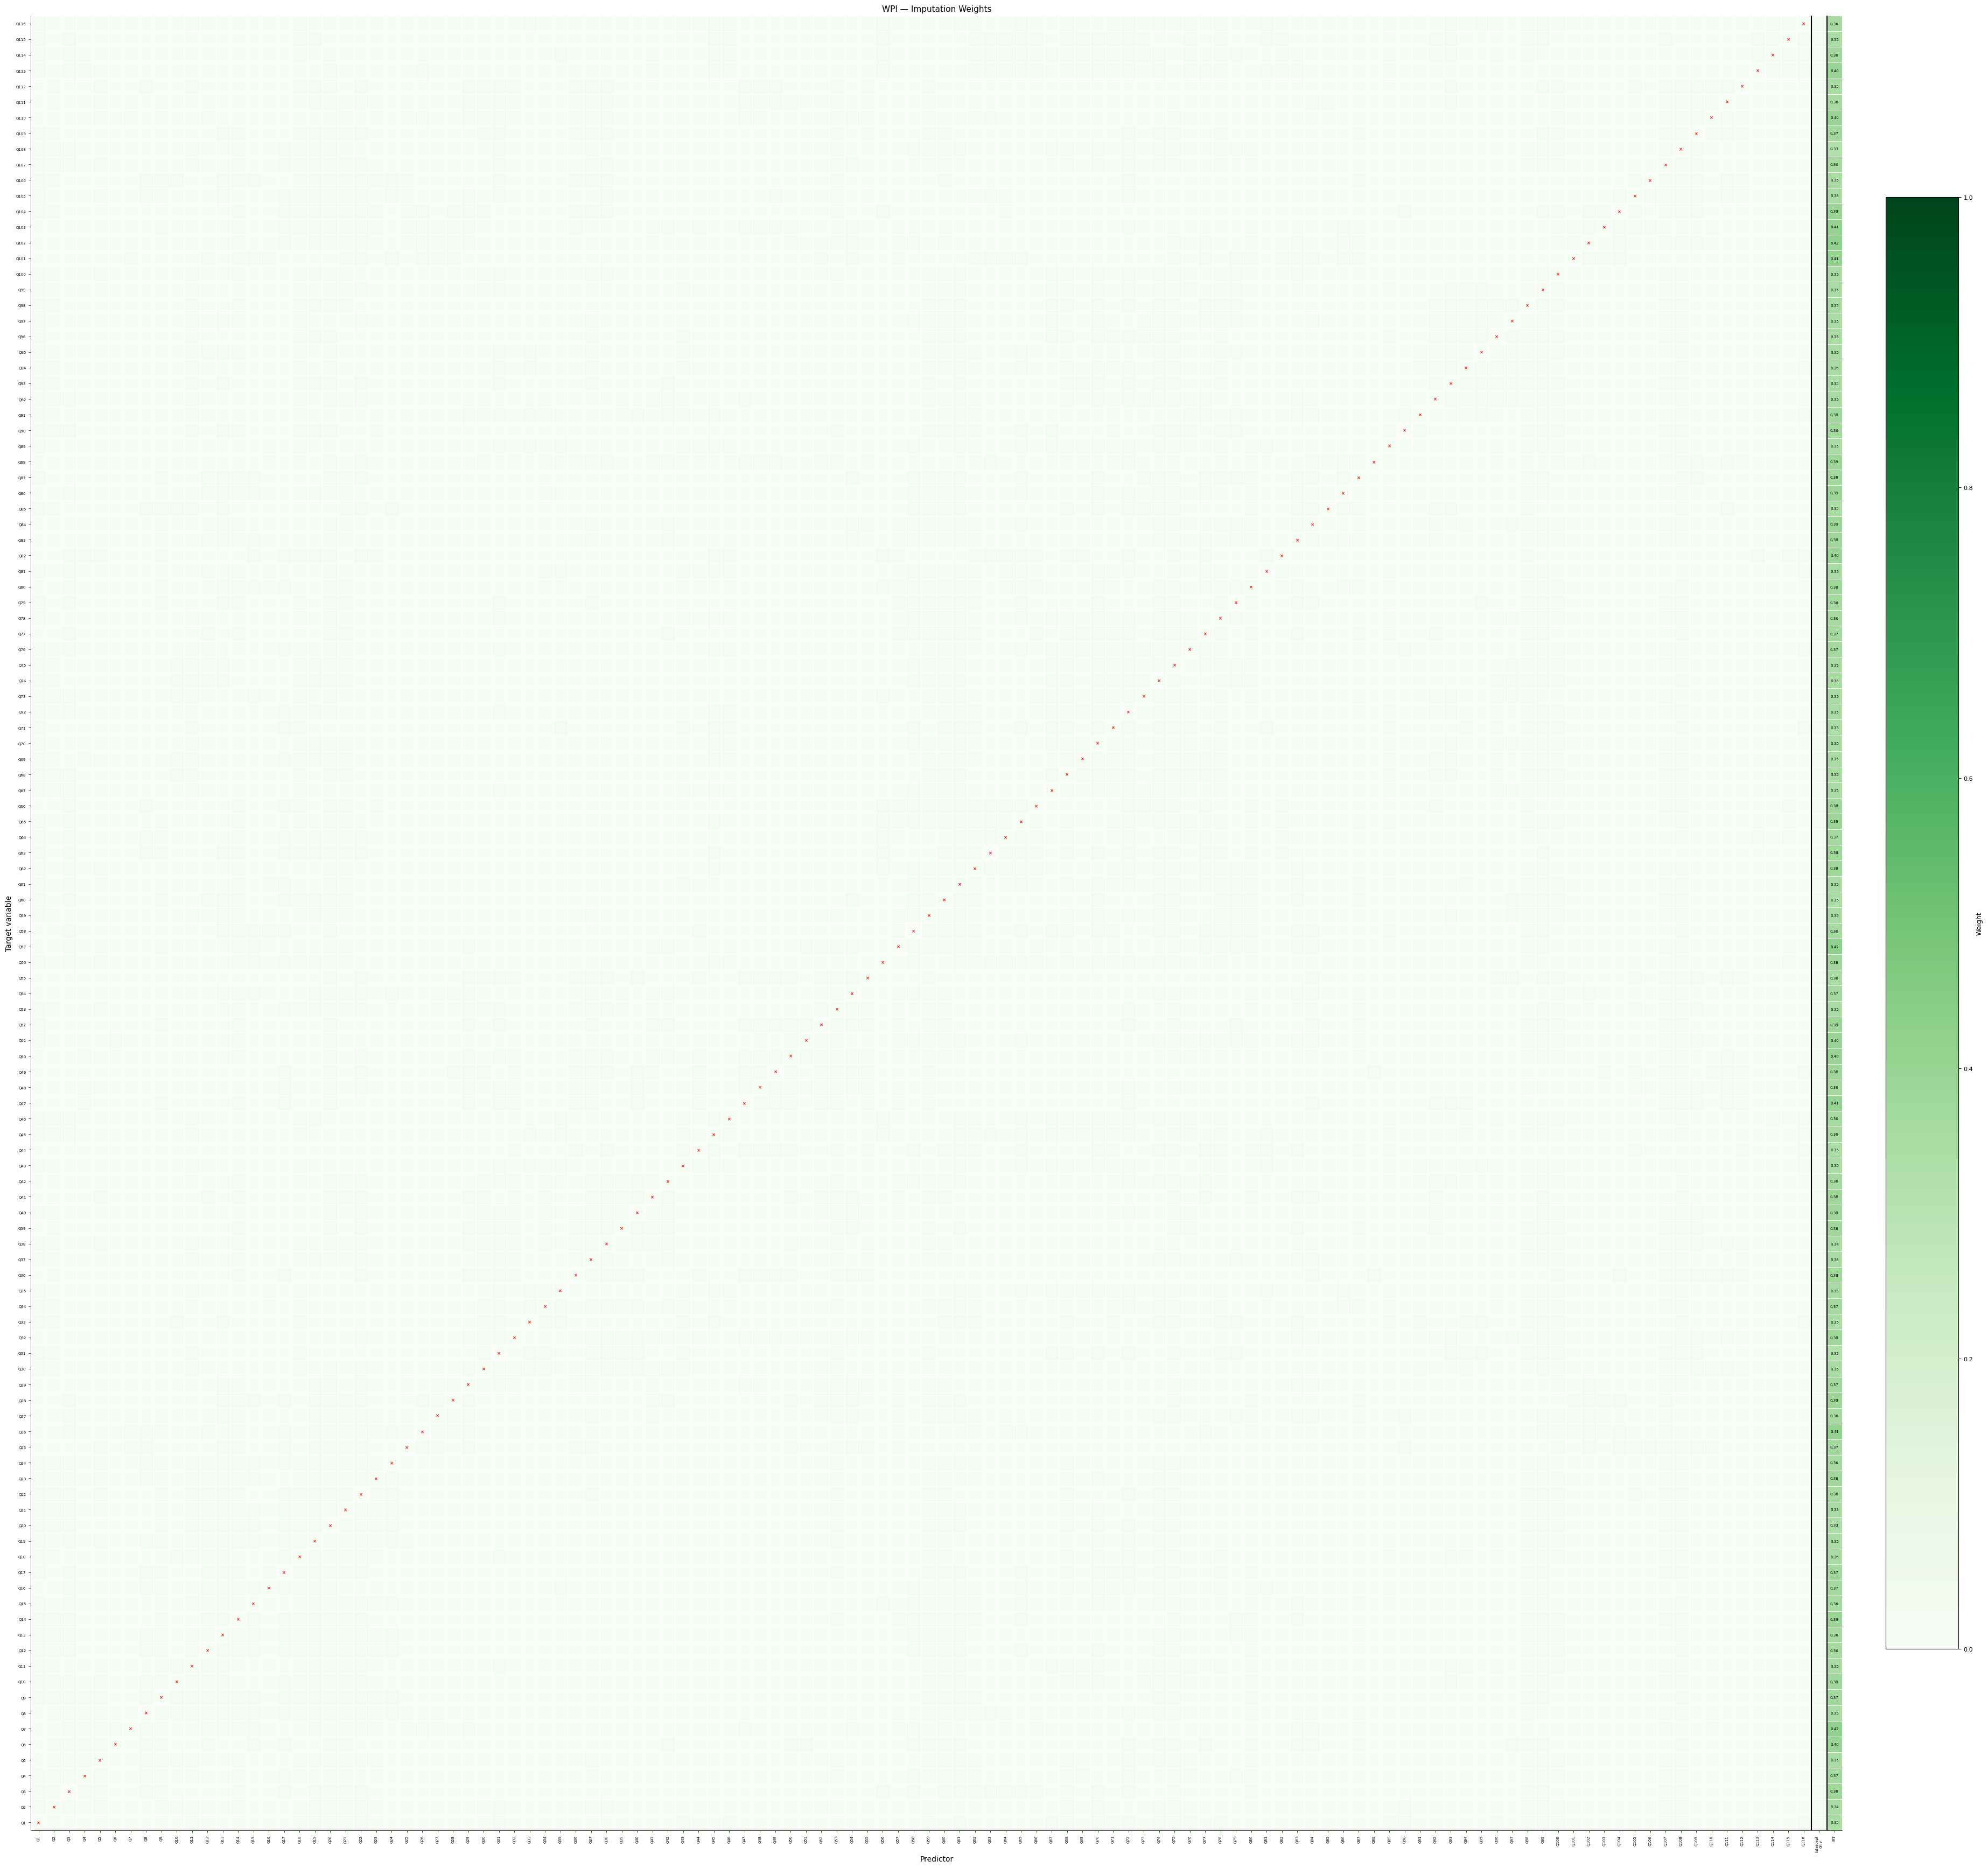

In [19]:
fig = plot_imputation_weights_pcolormesh(mice_loo, mixed_imputation, item_keys,
                                          title='WPI — Imputation Weights')
fig.savefig('imputation_weights.pdf', bbox_inches='tight', dpi=150)
plt.show()

## Summary

This notebook demonstrated fitting a single-scale GRM (equivalent to a 2PL model
for binary items) to the 116-item Woodworth Psychoneurotic Inventory:

1. **Baseline (ignorable missingness)**: Missing responses have their log-likelihood
   zeroed out.
2. **Mixed imputation (MICE + baseline IRT)**: A `MICEBayesianLOO` pairwise Bayesian
   model is blended with the baseline IRT model's marginalized predictions via per-item
   softmax weights over ELPD scores:
   `PMF = w_mice × MICE + (1 − w_mice) × IRT_baseline`.
3. **Analytic Rao-Blackwellized imputation**: The GRM analytically marginalizes over
   the blended imputation PMF for missing cells, yielding zero-variance contributions.

Discrimination and ability estimates from both approaches can be compared to assess
the impact of the missingness-handling strategy.